# Project2 - Exploratory Data Analysis (EDA)

This notebook explores the synthetic dataset generated for the project2 of IA.  
The dataset contains patient health indicators used to predict risk of **Diabetes** and **Hypertension**.

**Sections:**
1. Dataset Overview
2. Variable Distributions
3. Class Balance
4. Correlations with Targets

In [32]:
import pandas 
import numpy 
import matplotlib.pyplot as plt
import seaborn 

seaborn.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pandas.read_csv('data.csv')
print('Dataset loaded successfully!')

Dataset loaded successfully!


---
## Dataset Overview

In [33]:
df.head(10) #first 10 elem of the dataset

,age,sex,bmi,systolic_pressure,glucose,cholesterol,smoking,physical_activity,family_history_diabetes,family_history_hypertension,diabetes_risk,hypertension_risk
0,52,0,16.0,90,76,157,0,2,0,0,0,0
1,42,1,25.4,108,79,130,0,2,0,1,0,0
2,54,1,20.1,138,121,143,0,0,0,0,0,0
3,67,0,19.4,131,95,156,0,1,1,1,0,1
4,41,0,27.1,141,78,181,1,0,0,0,0,0
5,41,1,34.4,128,104,178,1,2,0,1,0,1
6,68,0,31.5,143,78,171,0,2,0,0,0,0
7,56,0,16.6,97,87,170,0,1,0,0,0,0
8,37,0,20.1,91,85,179,0,2,0,0,0,0
9,53,0,31.6,90,124,206,1,1,0,0,0,0


In [34]:
print('Column Types')
print(df.dtypes)
print()
print('Missing Values')
print(df.isnull().sum())
print()

Column Types
age                              int64
sex                              int64
bmi                            float64
systolic_pressure                int64
glucose                          int64
cholesterol                      int64
smoking                          int64
physical_activity                int64
family_history_diabetes          int64
family_history_hypertension      int64
diabetes_risk                    int64
hypertension_risk                int64
dtype: object

Missing Values
age                            0
sex                            0
bmi                            0
systolic_pressure              0
glucose                        0
cholesterol                    0
smoking                        0
physical_activity              0
family_history_diabetes        0
family_history_hypertension    0
diabetes_risk                  0
hypertension_risk              0
dtype: int64



In [35]:
df.describe().round(2) #statistical summary of vars

,age,sex,bmi,systolic_pressure,glucose,cholesterol,smoking,physical_activity,family_history_diabetes,family_history_hypertension,diabetes_risk,hypertension_risk
count,852.00,852.0,852.00,852.00,852.00,852.00,852.00,852.00,852.00,852.00,852.00,852.00
mean,44.59,0.5,26.33,112.10,100.17,179.19,0.24,0.79,0.29,0.35,0.21,0.27
std,14.16,0.5,5.71,16.48,21.05,28.38,0.43,0.75,0.45,0.48,0.41,0.45
min,18.00,0.0,16.00,90.00,70.00,130.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,34.00,0.0,22.10,97.00,84.00,157.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,45.00,1.0,26.10,112.00,99.00,179.00,0.00,1.00,0.00,0.00,0.00,0.00
75%,54.00,1.0,30.12,125.00,115.00,198.00,0.00,1.00,1.00,1.00,0.00,1.00
max,80.00,1.0,45.00,169.00,175.00,271.00,1.00,2.00,1.00,1.00,1.00,1.00


---
## Variable Distributions

### Numeric Variables

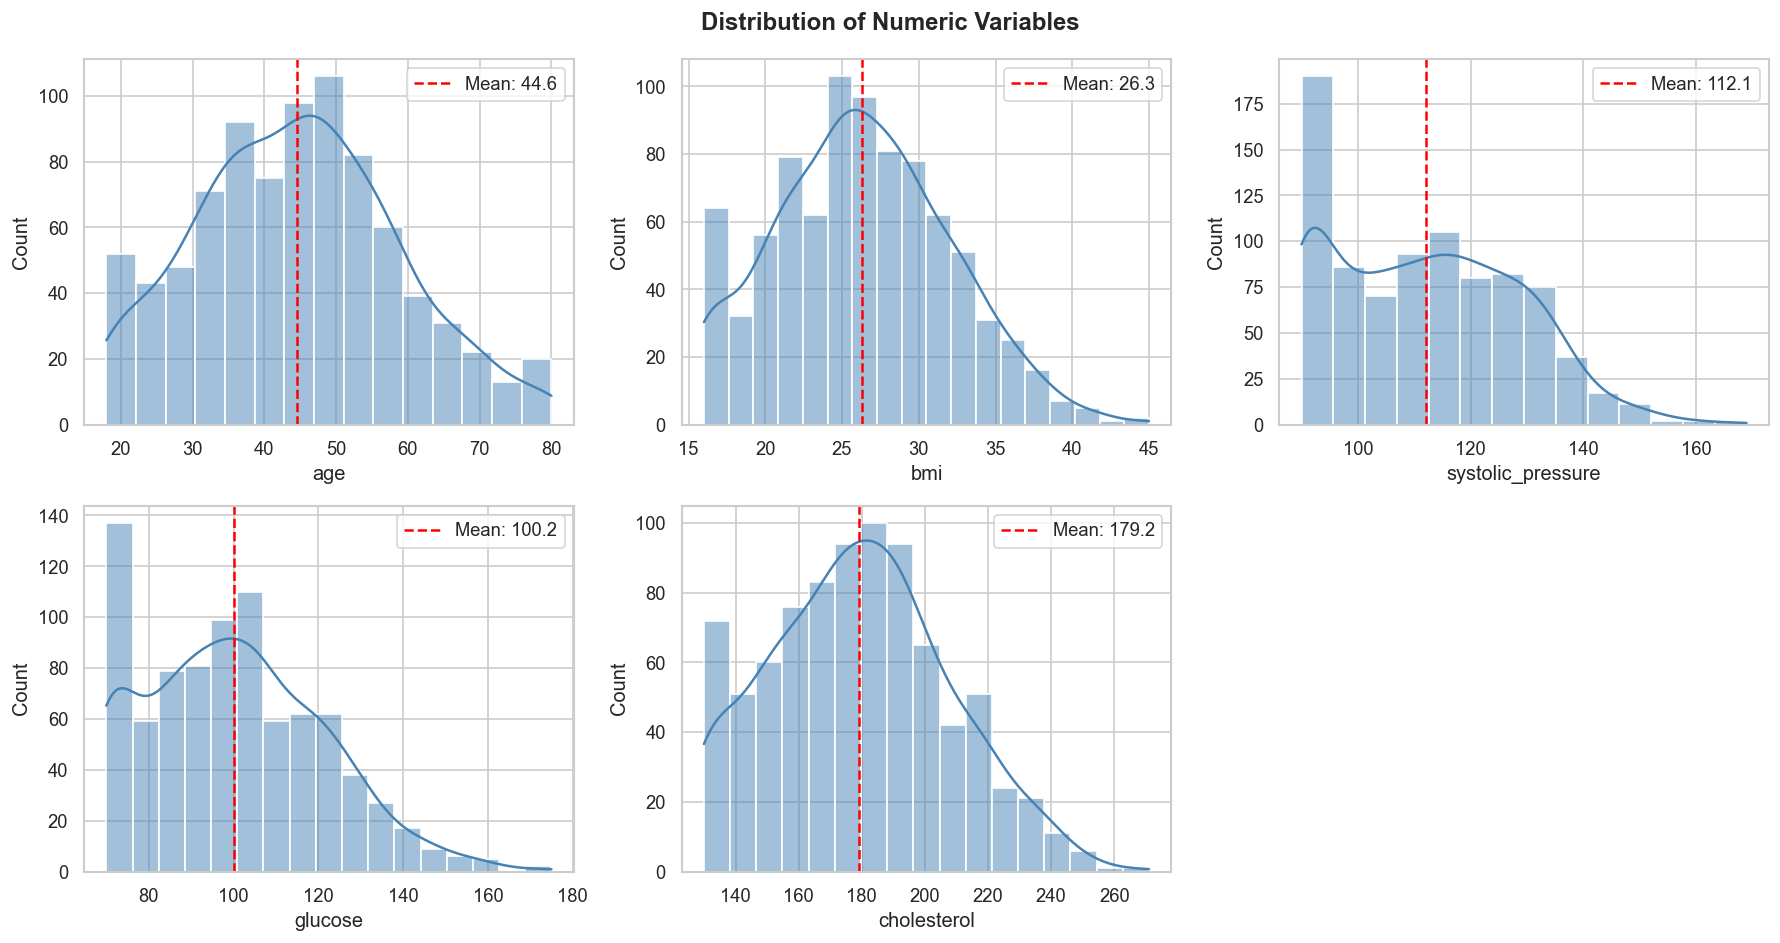

In [43]:
numeric_cols = ['age', 'bmi', 'systolic_pressure', 'glucose', 'cholesterol']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    seaborn.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    
    mean_val = df[col].mean() #cals the mean of each graph
    
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].legend()

axes[-1].axis('off')  #hide last spot since its only 5 graphs
fig.suptitle('Distribution of Numeric Variables', fontweight='bold')
plt.tight_layout()
plt.show()

### Binary and Ordinal Variables
Frequency counts for categorical features.

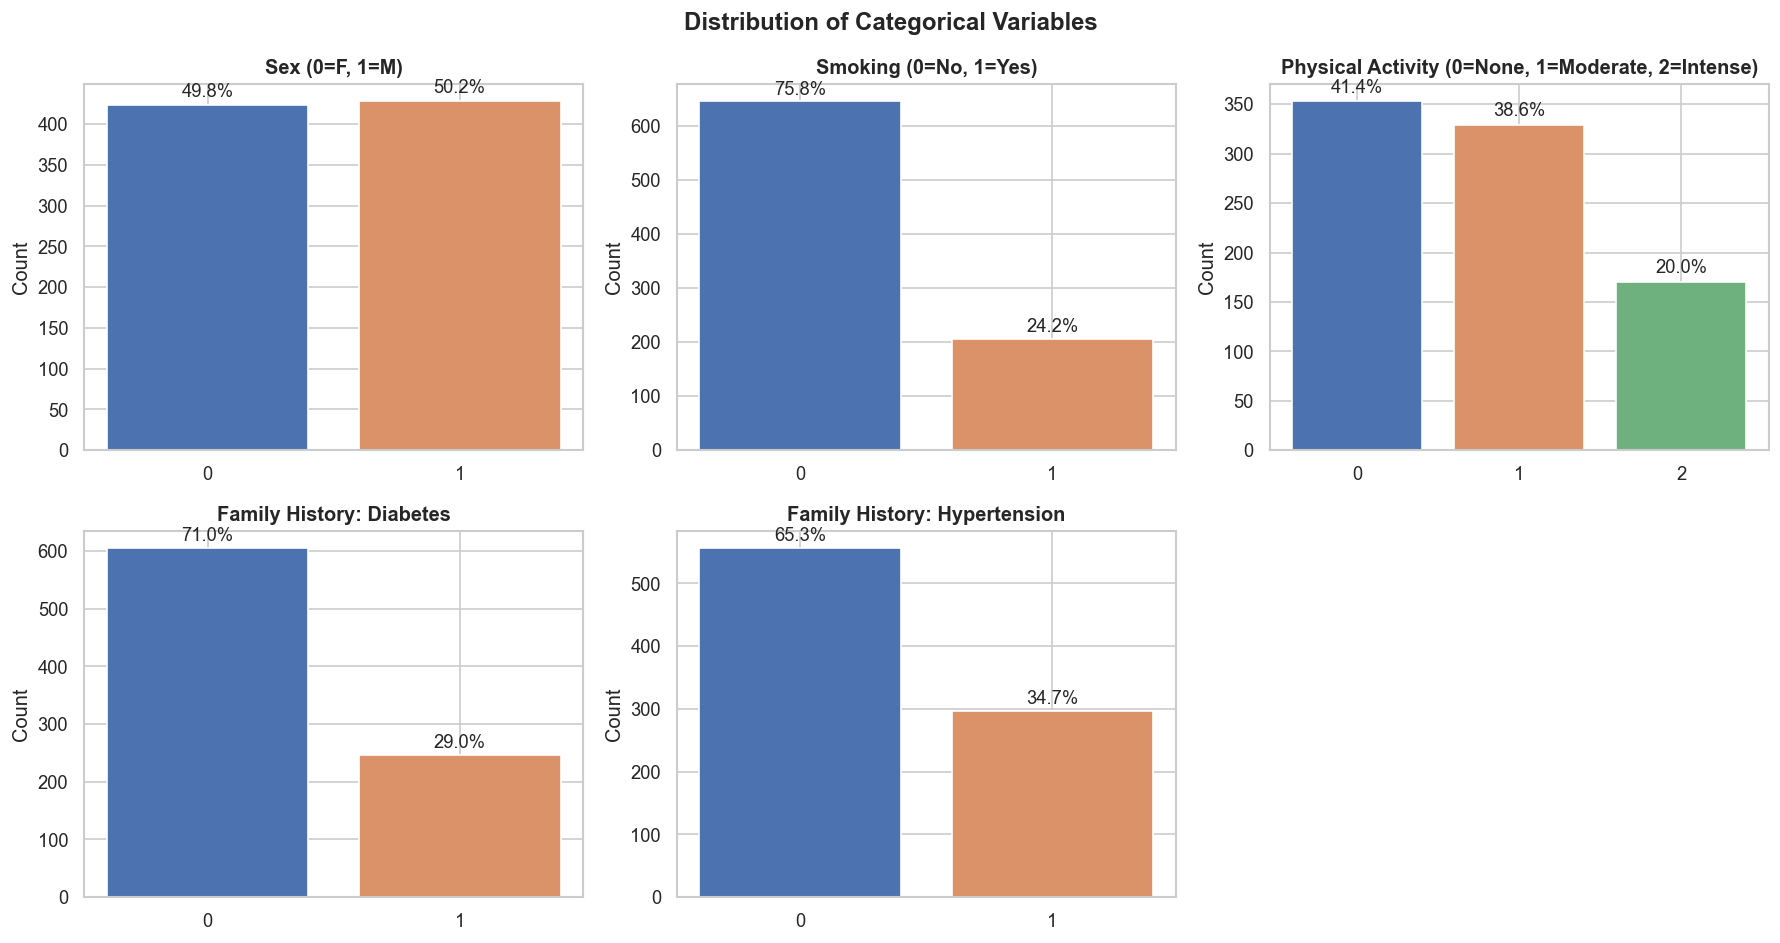

In [37]:
cat_cols = ['sex', 'smoking', 'physical_activity', 'family_history_diabetes', 'family_history_hypertension']
cat_labels = ['Sex (0=F, 1=M)', 'Smoking (0=No, 1=Yes)', 'Physical Activity (0=None, 1=Moderate, 2=Intense)',
              'Family History: Diabetes', 'Family History: Hypertension']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = ['#4C72B0', "#DB9268", "#6EB17E"]

for i, (col, label) in enumerate(zip(cat_cols, cat_labels)):
    counts = df[col].value_counts().sort_index() #count how many times each value apears
    
    bars = axes[i].bar(counts.index.astype(str), counts.values, color=colors[:len(counts)])
    
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_ylabel('Count')
    
    for bar in bars:
        height = bar.get_height()
        percentage = height / len(df) * 100
        
        axes[i].text(bar.get_x() + bar.get_width()/2, height + 5, f'{percentage:.1f}%',ha='center', va='bottom', fontsize=11)

axes[-1].axis('off')
fig.suptitle('Distribution of Categorical Variables', fontweight='bold')
plt.tight_layout()
plt.show()

---

## Balance

Check the balance of the dataset

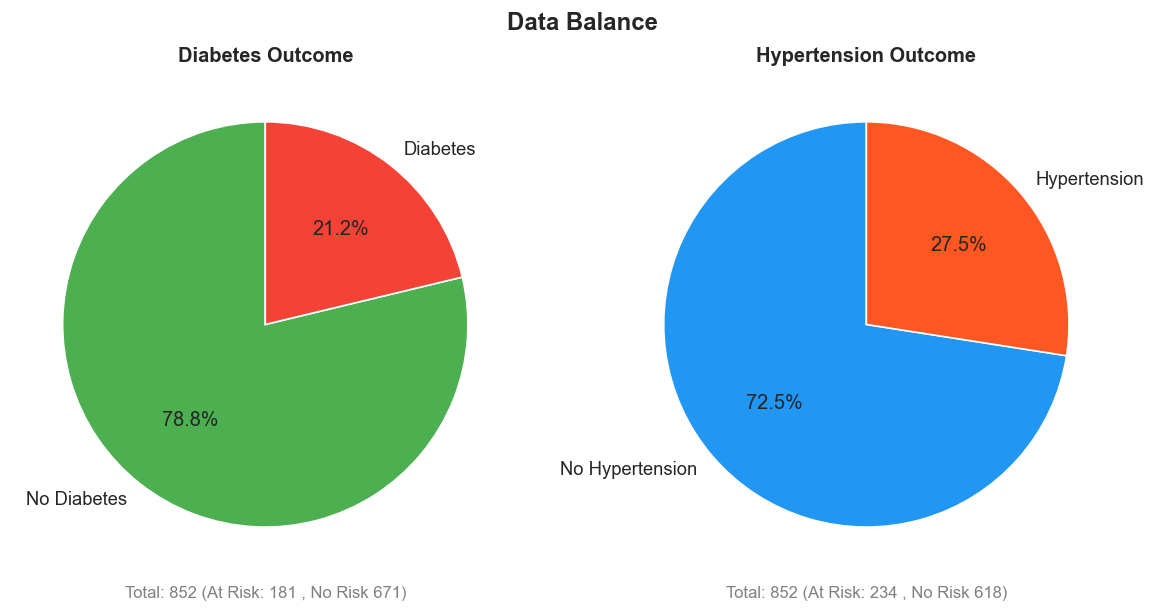

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

graph_labels = [
    ['No Diabetes', 'Diabetes'],
    ['No Hypertension', 'Hypertension']
]

for ax, col, title, colors, labels in zip(
    axes,
    ['diabetes_risk', 'hypertension_risk'],
    ['Diabetes Outcome', 'Hypertension Outcome'],
    [['#4CAF50', '#F44336'], ['#2196F3', '#FF5722']],
    graph_labels
):
    counts = df[col].value_counts().sort_index()
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=labels,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
    )
    
    ax.set_title(title, fontweight='bold')
   
    ax.text(0, -1.35, f'Total: {len(df)} (At Risk: {counts[1]} , No Risk {counts[0]})',
            ha='center', fontsize=10, color='grey')

fig.suptitle('Data Balance', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Correlations with Targets

### Correlation Heatmap
Overview of linear correlations between all variables.


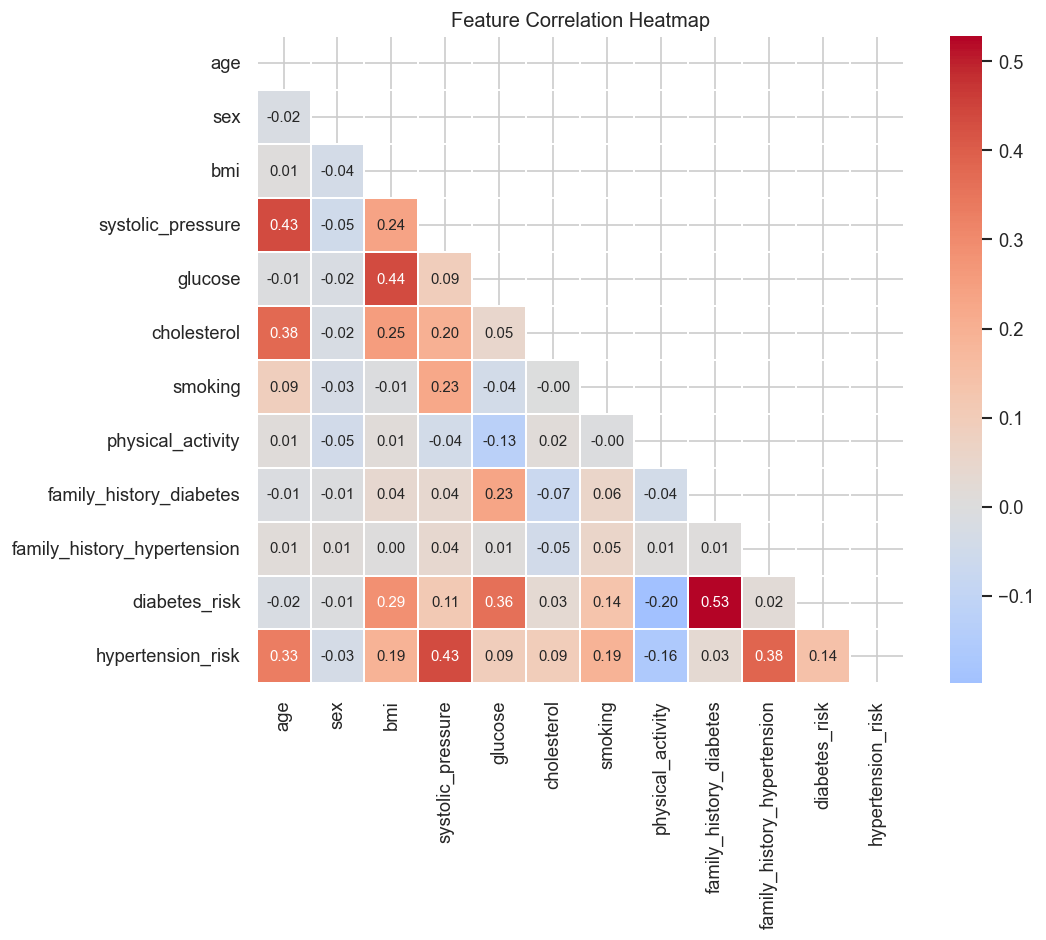

In [40]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = numpy.triu(numpy.ones_like(corr, dtype=bool))
seaborn.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1,   annot_kws={'size': 9}) 
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()



### Boxplots: Numeric Features by Target
Comparing feature distributions between patients with and without risk.

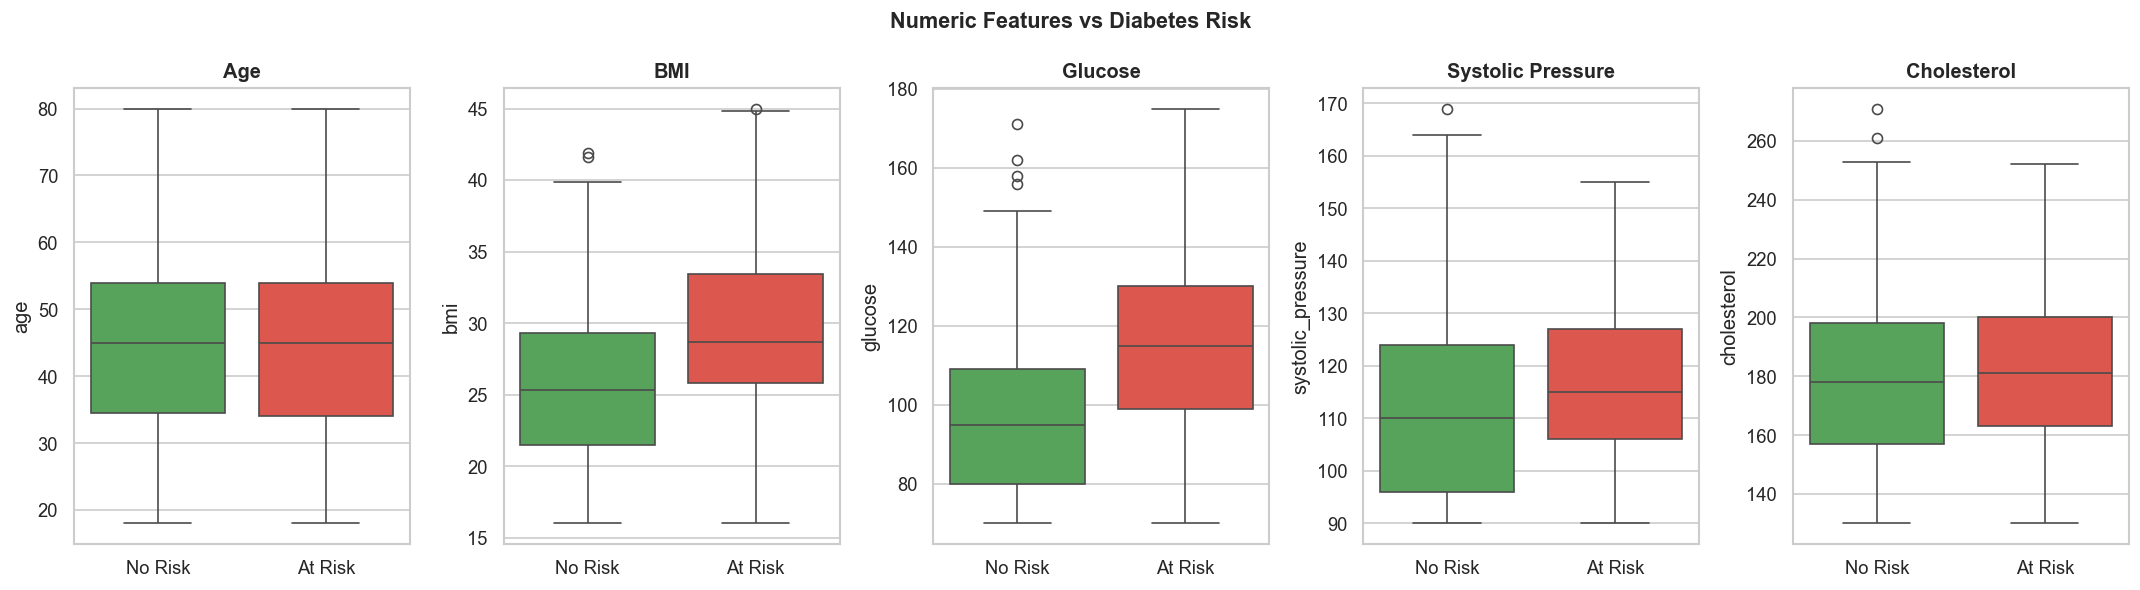

In [48]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col, label in zip(axes, numeric_cols, numeric_labels):
    seaborn.boxplot(data=df, x='diabetes_risk', y=col, ax=ax,
                hue='diabetes_risk', palette=['#4CAF50', '#F44336'], legend=False)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Risk', 'At Risk'])

fig.suptitle('Numeric Features vs Diabetes Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

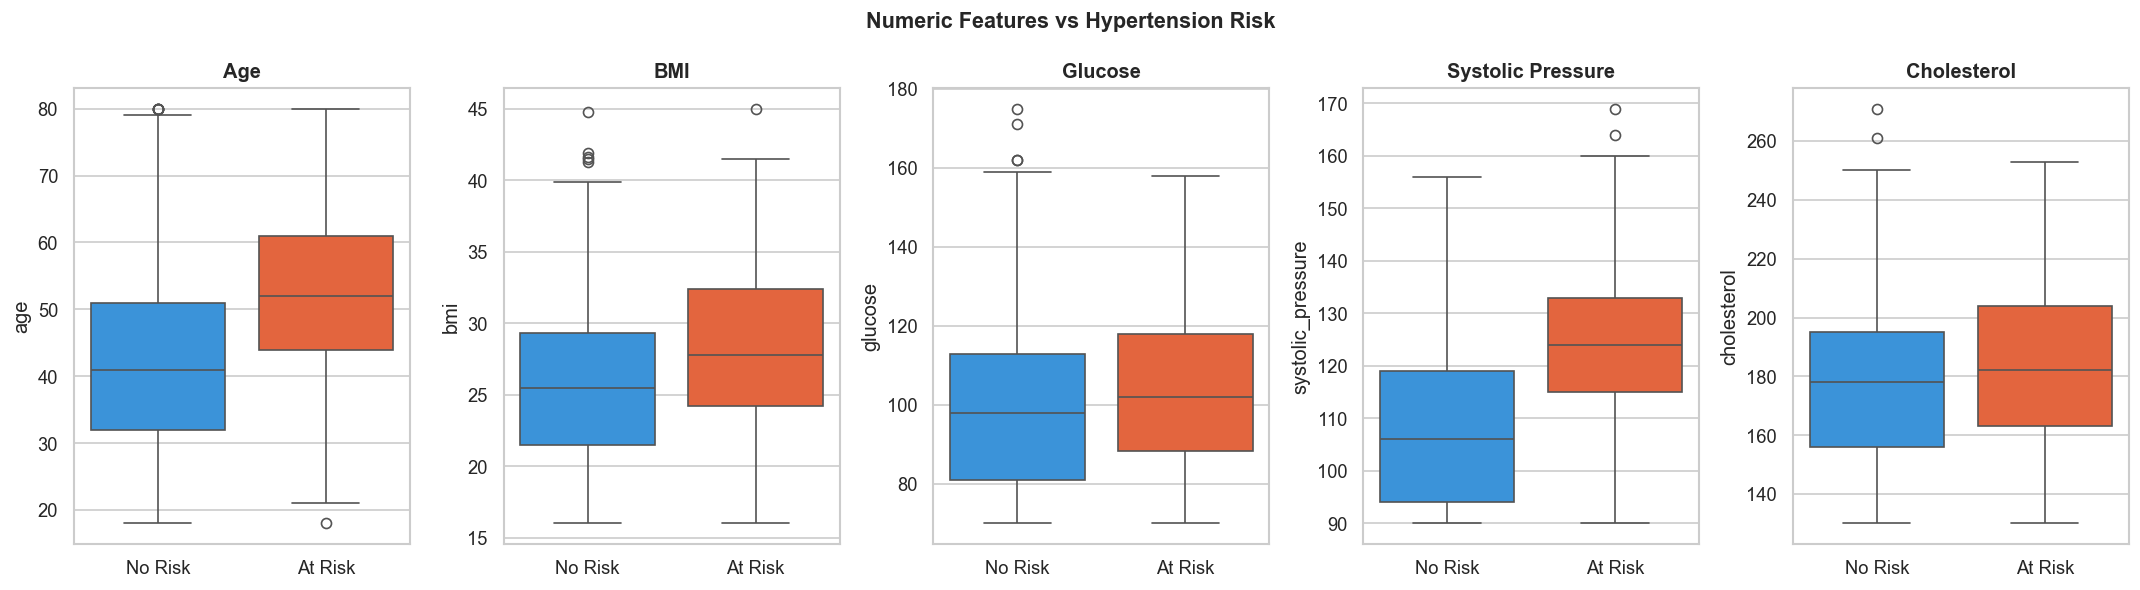

In [49]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col, label in zip(axes, numeric_cols, numeric_labels):
    seaborn.boxplot(data=df, x='hypertension_risk', y=col, ax=ax,
                hue='hypertension_risk', palette=['#2196F3', '#FF5722'], legend=False)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Risk', 'At Risk'])

fig.suptitle('Numeric Features vs Hypertension Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Correlation with Each Target
Bar chart showing which features are most correlated with each risk.

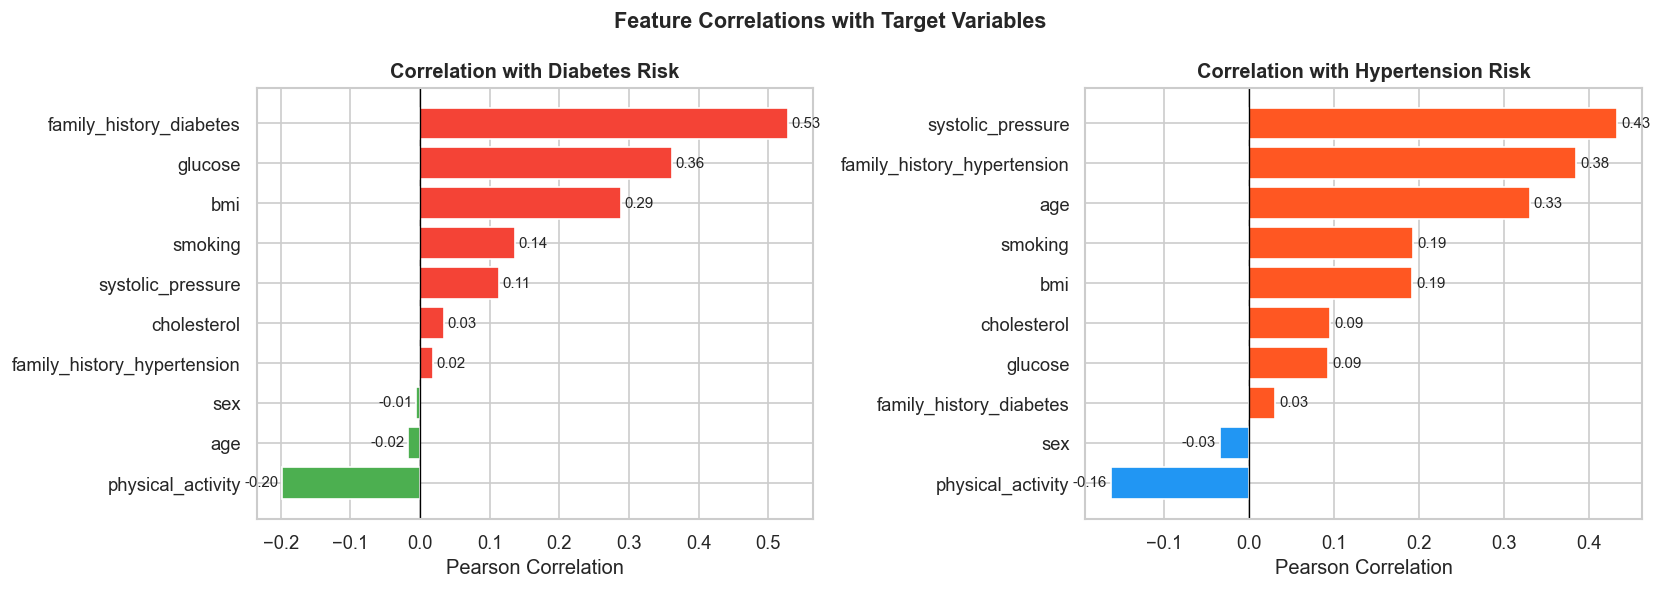

In [50]:
features = ['age', 'sex', 'bmi', 'systolic_pressure', 'glucose', 'cholesterol',
            'smoking', 'physical_activity', 'family_history_diabetes', 'family_history_hypertension']

corr_diabetes = df[features + ['diabetes_risk']].corr()['diabetes_risk'][features].sort_values()
corr_hypert   = df[features + ['hypertension_risk']].corr()['hypertension_risk'][features].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, corr_vals, title, color_pos, color_neg in zip(
    axes,
    [corr_diabetes, corr_hypert],
    ['Correlation with Diabetes Risk', 'Correlation with Hypertension Risk'],
    ['#F44336', '#FF5722'],
    ['#4CAF50', '#2196F3']
):
    colors = [color_pos if v > 0 else color_neg for v in corr_vals]
    bars = ax.barh(corr_vals.index, corr_vals.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Pearson Correlation')
    for bar, val in zip(bars, corr_vals.values):
        ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

fig.suptitle('Feature Correlations with Target Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()